# House Price Prediction Using Linear Regression

## Objective

The objective of this project is to build a Linear Regression model that predicts the price of a house based on its features such as area, number of bedrooms, bathrooms, stories, parking spaces, and other amenities.

## Dataset

- Source: Kaggle
- Dataset: Housing Prices Dataset
- Target Variable: Price

## Workflow

1. Import Libraries
2. Load Dataset
3. Explore the Dataset
4. Clean the Data/CSV
5. Perform Exploratory Data Analysis (EDA)
6. Preprocess the Data
7. Split the Data into Training and Testing Sets
8. Train a Linear Regression Model
9. Evaluate the Model
10. Draw Conclusions

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display plots inside notebook
%matplotlib inline

### Import Dataset

In [5]:
df = pd.read_csv("../data/housing-prices-dataset/Housing.csv")

### Data Explortion

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape    # (rows, columns)

(545, 13)

In [ ]:
df.columns  # All columns in the dataset

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [10]:
df.info()   # Data types of each column and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [11]:
df.describe()  # Summary statistics of the numerical columns

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Check Missing Values

- df.isnull() 

False = No missing value
True = Missing value

- df.isnumm().sum()

This counts the number of True values (missing values) in each column.

In [16]:
df.isnull()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,False,False,False,False,False,False,False,False,False,False,False,False,False
541,False,False,False,False,False,False,False,False,False,False,False,False,False
542,False,False,False,False,False,False,False,False,False,False,False,False,False
543,False,False,False,False,False,False,False,False,False,False,False,False,False


In [17]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [21]:
df.duplicated() # Check for duplicate rows

0      False
1      False
2      False
3      False
4      False
       ...  
540    False
541    False
542    False
543    False
544    False
Length: 545, dtype: bool

In [22]:
df.duplicated().sum()   # Count of duplicate rows

np.int64(0)

In [28]:
df.sample(5, random_state=42)    # Random sample of 5 rows

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,4060000,5900,4,2,2,no,no,yes,no,no,1,no,unfurnished
77,6650000,6500,3,2,3,yes,no,no,no,yes,0,yes,furnished
360,3710000,4040,2,1,1,yes,no,no,no,no,0,no,semi-furnished
90,6440000,5000,3,1,2,yes,no,no,no,yes,0,no,semi-furnished
493,2800000,3960,3,1,1,yes,no,no,no,no,0,no,furnished


### Why `random_state=42`?

Many functions in Python and Scikit-learn use randomness (e.g., `sample()`, `train_test_split()`). By default, the output changes every time the code is run.

The `random_state` parameter sets a fixed **seed** for the random number generator, ensuring that the same random results are produced every time the code is executed. This makes experiments **reproducible** and allows others to obtain the exact same results.

The value **42** has no special meaning in machine learning—it is simply a commonly used convention in programming. Any integer (e.g., `0`, `7`, `100`) can be used as the seed.

**Example:**

- `df.sample(5)` → Different 5 rows each time.
- `df.sample(5, random_state=42)` → The same 5 rows every time.

## Exploratory Data Analysis (EDA)

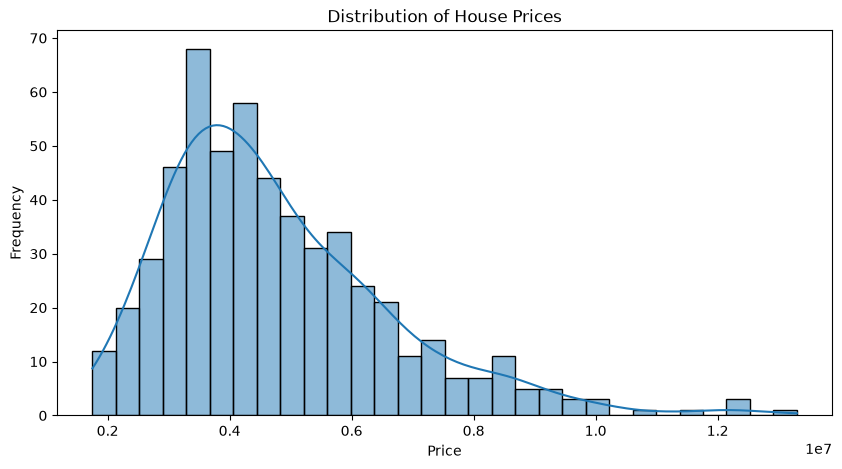

In [40]:
plt.figure(figsize=(10, 5))

# KDE stands for Kernel Density Estimation.
# It draws a smooth curve over the histogram.
sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()
